In [1]:
import pandas as pd
from cartopy import crs as ccrs
import xarray as xr
from xhistogram.xarray import histogram
import numpy as np
# import gfdl_utils as gu
import glob
import re
from scipy.interpolate import griddata
import geopy
import cmocean.cm as cmo
import cmocean
import gsw
from geopy import distance
import xesmf as xe
# import sectionate
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook")
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
import warnings
import gsw

In [2]:
import regionmask
from xmip.preprocessing import combined_preprocessing
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

In [3]:
# GLODAP:model variable naming conventions
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'},
    'cfc11':{'conversion':1e12/1035,'cmap':cmo.matter_r,'units':r'pmol kg$^{-1}$'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK'},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C'},
    'ct':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C'},
    'sa':{'conversion':1,'cmap':cmocean.cm.haline,'units':r'g kg$^{-1}$'},
    'so':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu'},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu'}, 
    'density':{'conversion':1,'cmap':cmocean.cm.dense,'units':r'kg m$^{-3}$'},
    'rho2':{'conversion':1,'cmap':cmocean.cm.dense,'units':r'kg m$^{-3}$'},

    'agessc':{'conversion':1,'cmap':cmocean.cm.speed,'units':'years'},
    'normalized_age':{'conversion':1,'cmap':cmocean.cm.speed,'units':'years'}
    
}

In [3]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/" + x
ds_zonal_avg = xr.open_dataset(datadir("SO_Weddell_section_Tracer_Zonal_sigma2.nc"))
ds_zonal_avg = ds_zonal_avg.where(ds_zonal_avg.rho2 != np.nan)

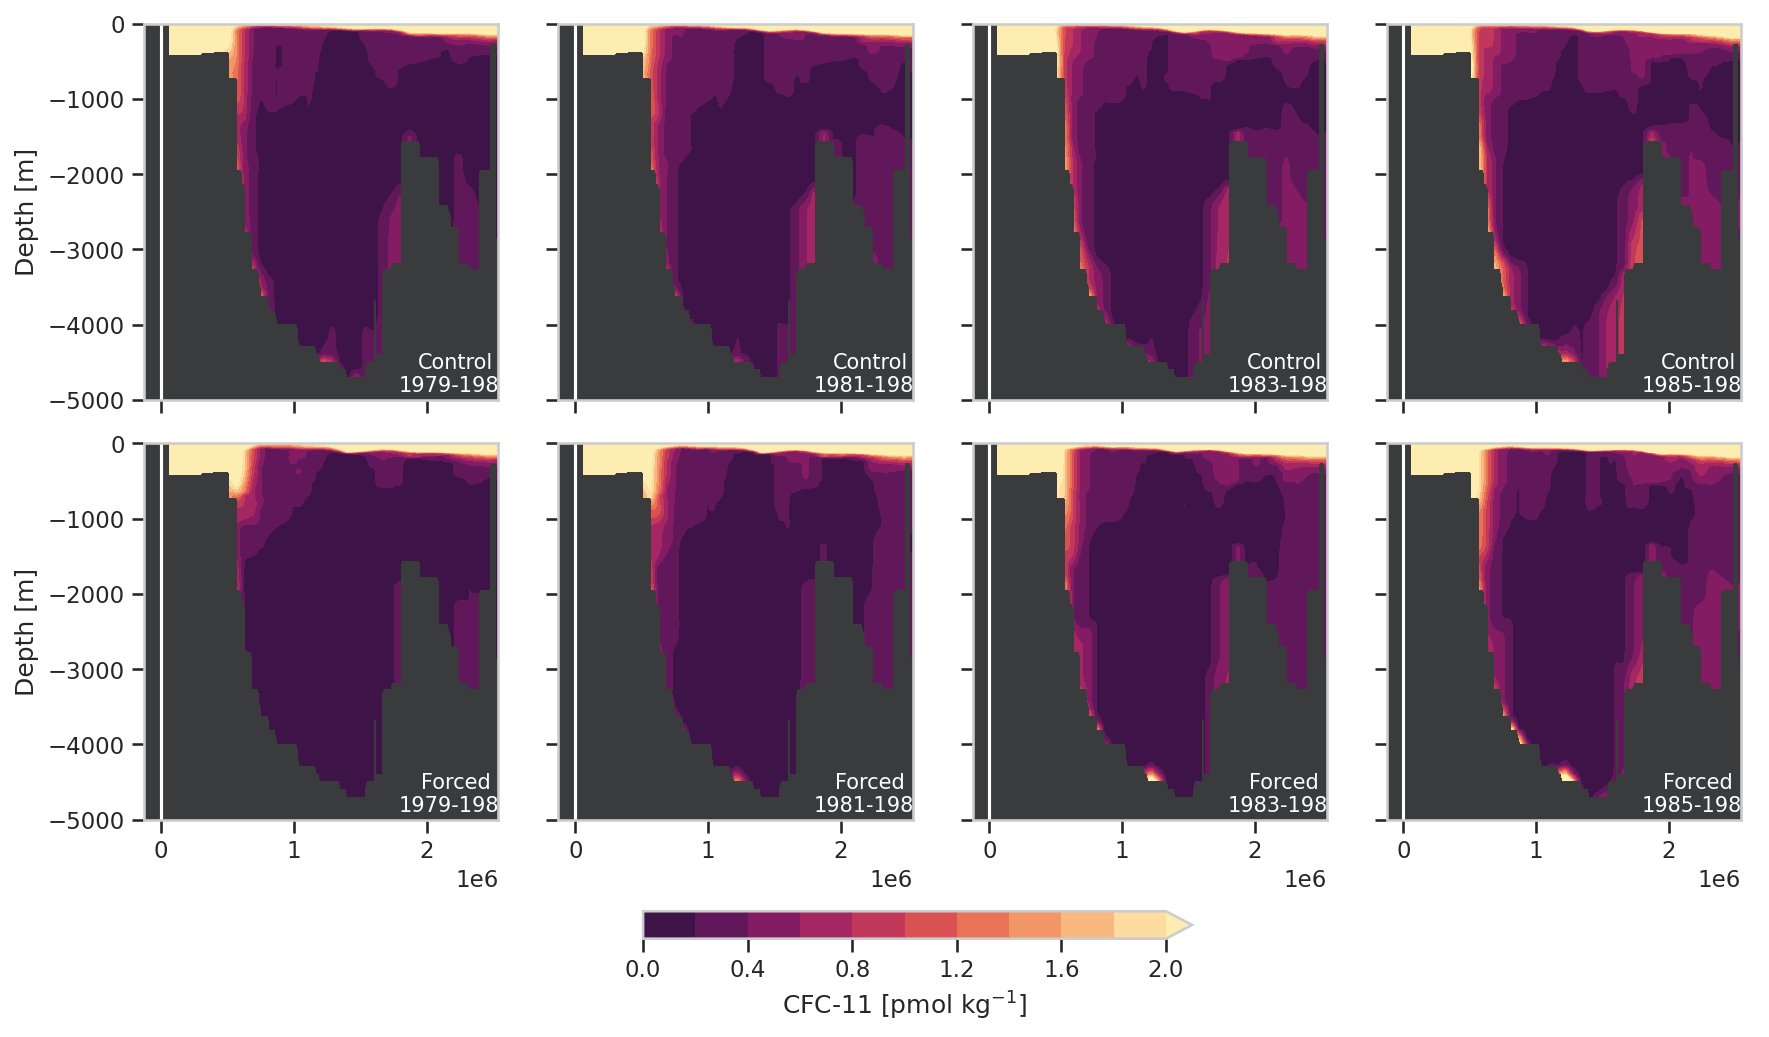

In [11]:
time_slices = [("1979", "1981"), ("1981", "1983"), ("1983", "1985"), ("1985", "1987")]
expts = ["control", "forced"]
variable = "cfc11"; variable_name = "CFC-11"; 
vmin = 0; vmax = 2; levels = np.arange(vmin, vmax + 1e-14, 0.2)
extend = "max"

fig, axes = plt.subplots(2, 4, figsize = (12, 7), sharey = True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):

        cb = plot_zonal_average_period(ds_zonal_avg, variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-5000, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

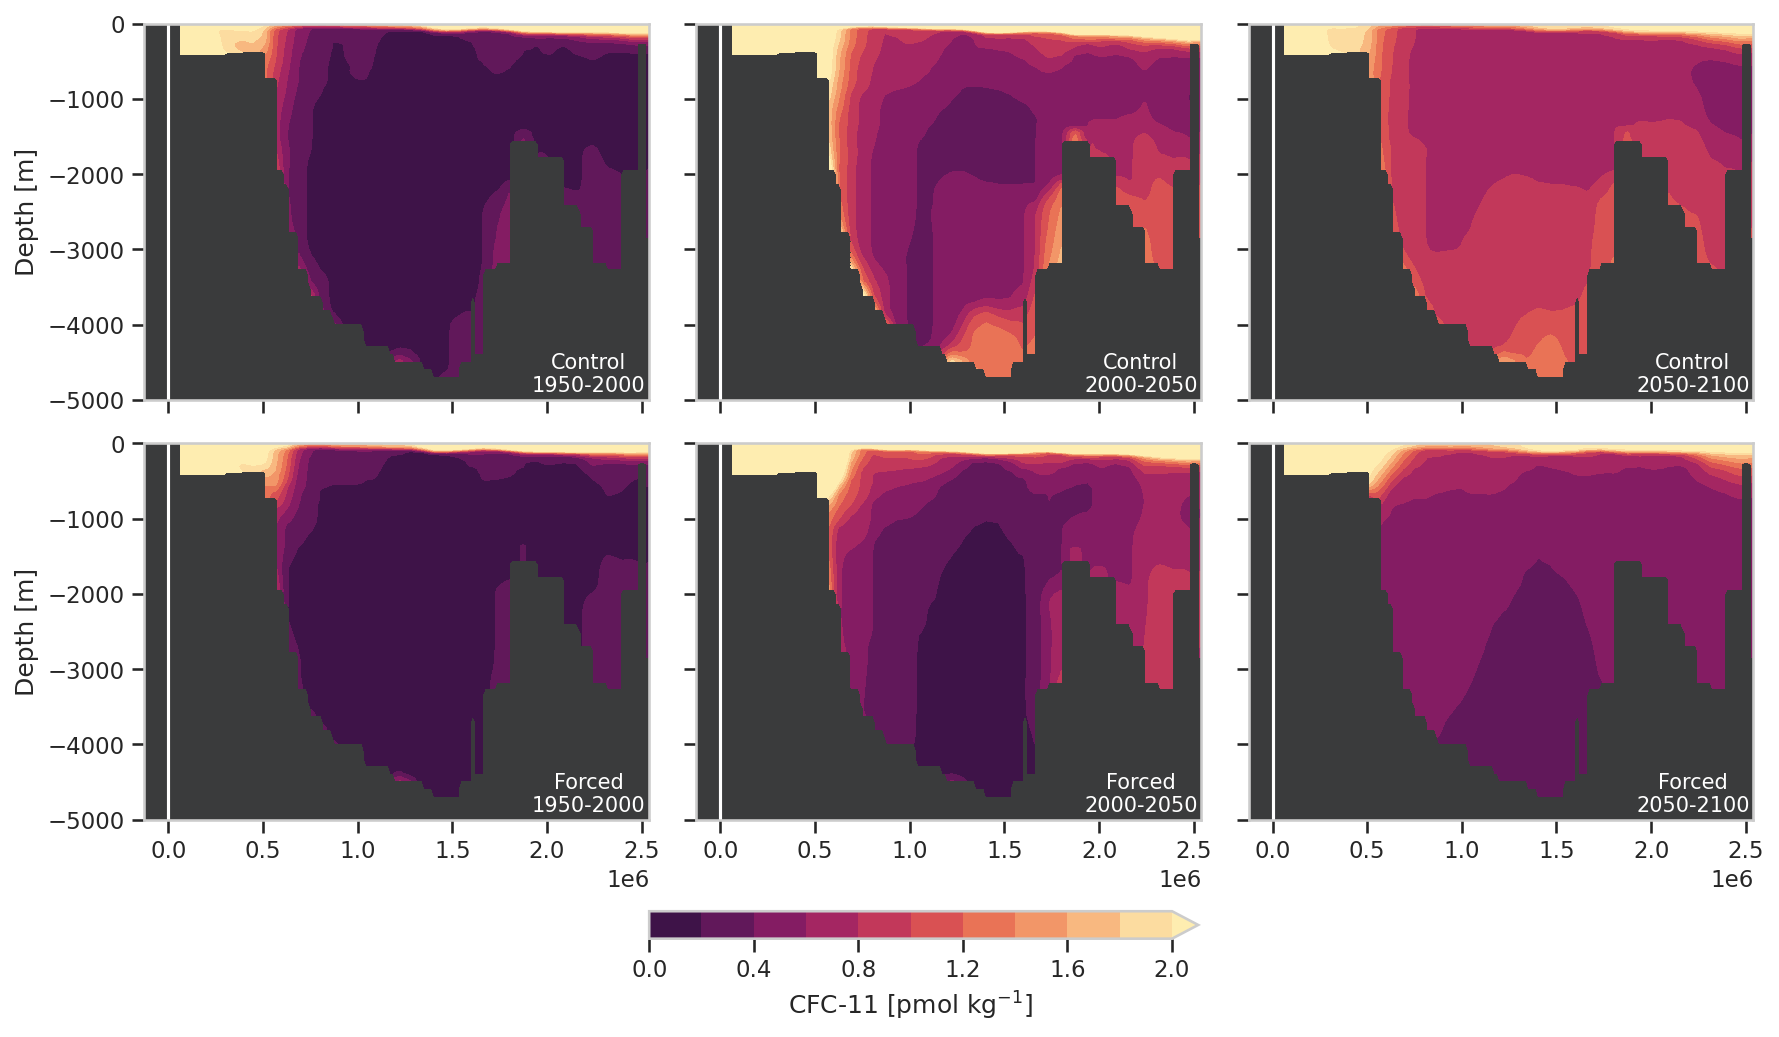

In [12]:
time_slices = [("1950", "2000"), ("2000", "2050"),  ("2050", "2100")]
expts = ["control", "forced"]
variable = "cfc11"; variable_name = "CFC-11"; 
vmin = 0; vmax = 2; levels = np.arange(vmin, vmax + 1e-14, 0.2)
extend = "max"

fig, axes = plt.subplots(2, 3, figsize = (12, 7), sharey = True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):

        cb = plot_zonal_average_period(ds_zonal_avg, variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-5000, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

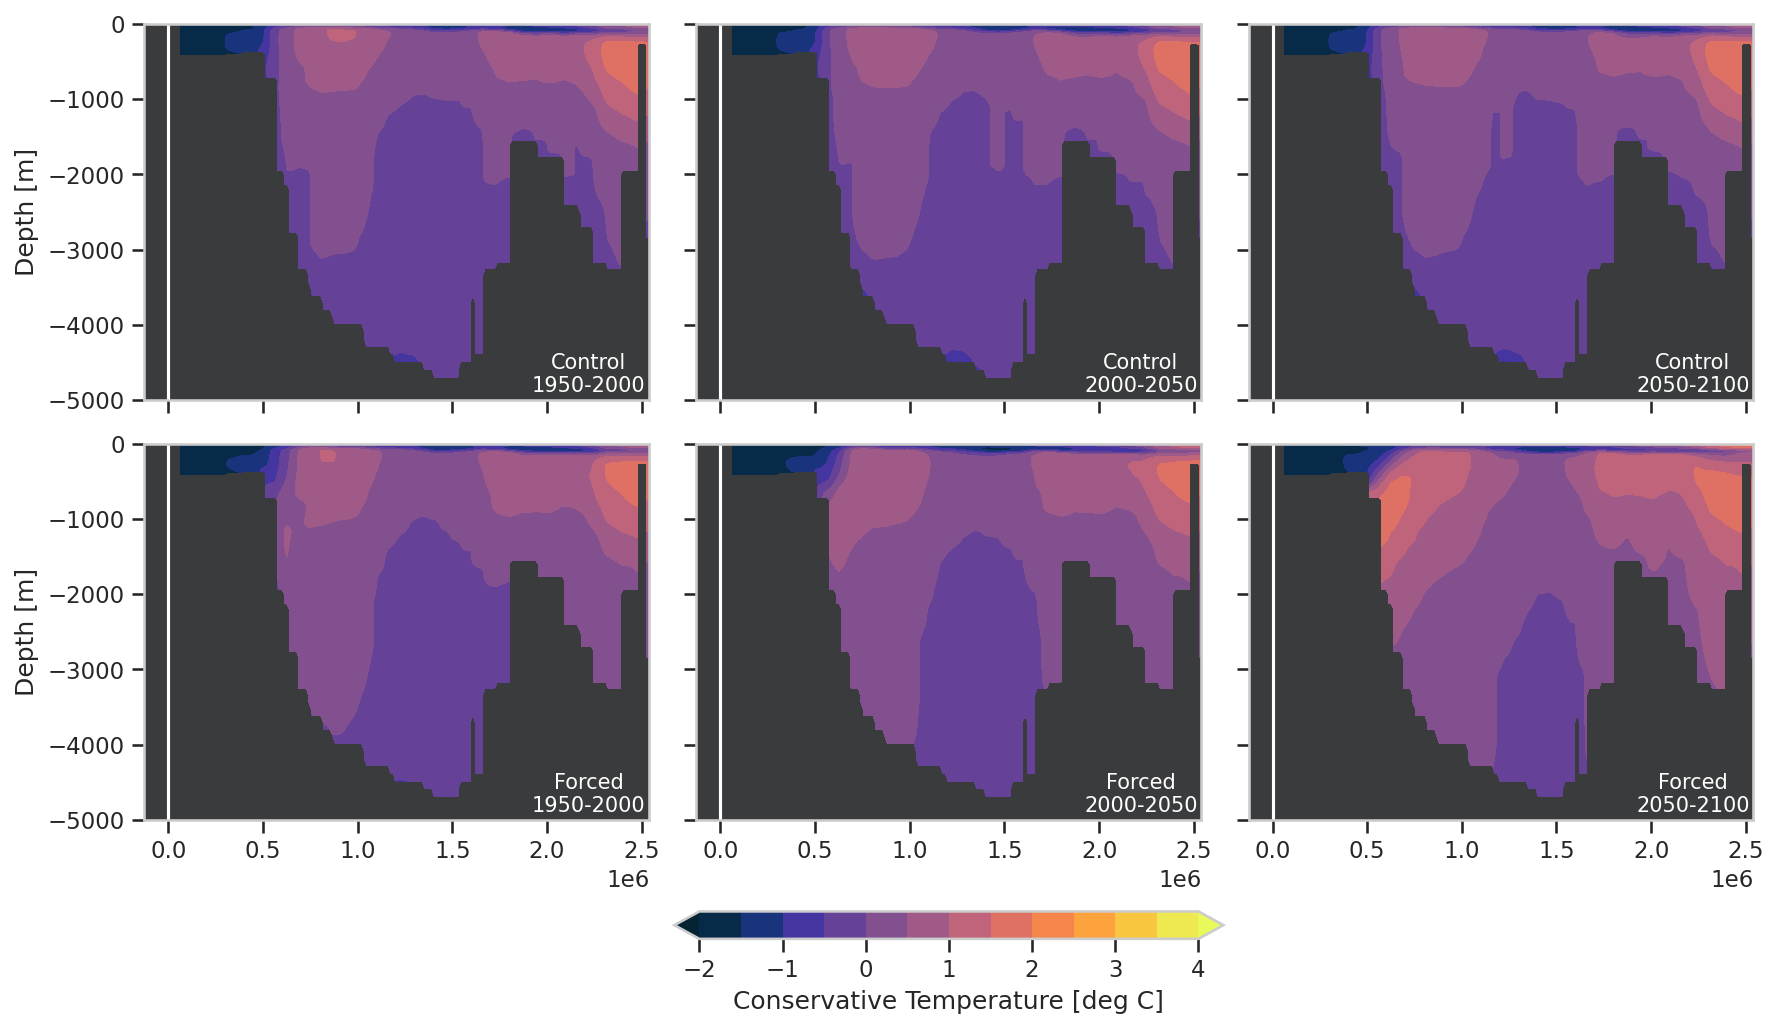

In [13]:
time_slices = [("1950", "2000"), ("2000", "2050"),  ("2050", "2100")]
expts = ["control", "forced"]
variable = "ct"; variable_name = "Conservative Temperature"; 
vmin = -2; vmax = 4; levels = np.arange(vmin, vmax + 1e-14, 0.5)
extend = "both"

fig, axes = plt.subplots(2, 3, figsize = (12, 7), sharey = True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):

        cb = plot_zonal_average_period(ds_zonal_avg, variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-5000, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

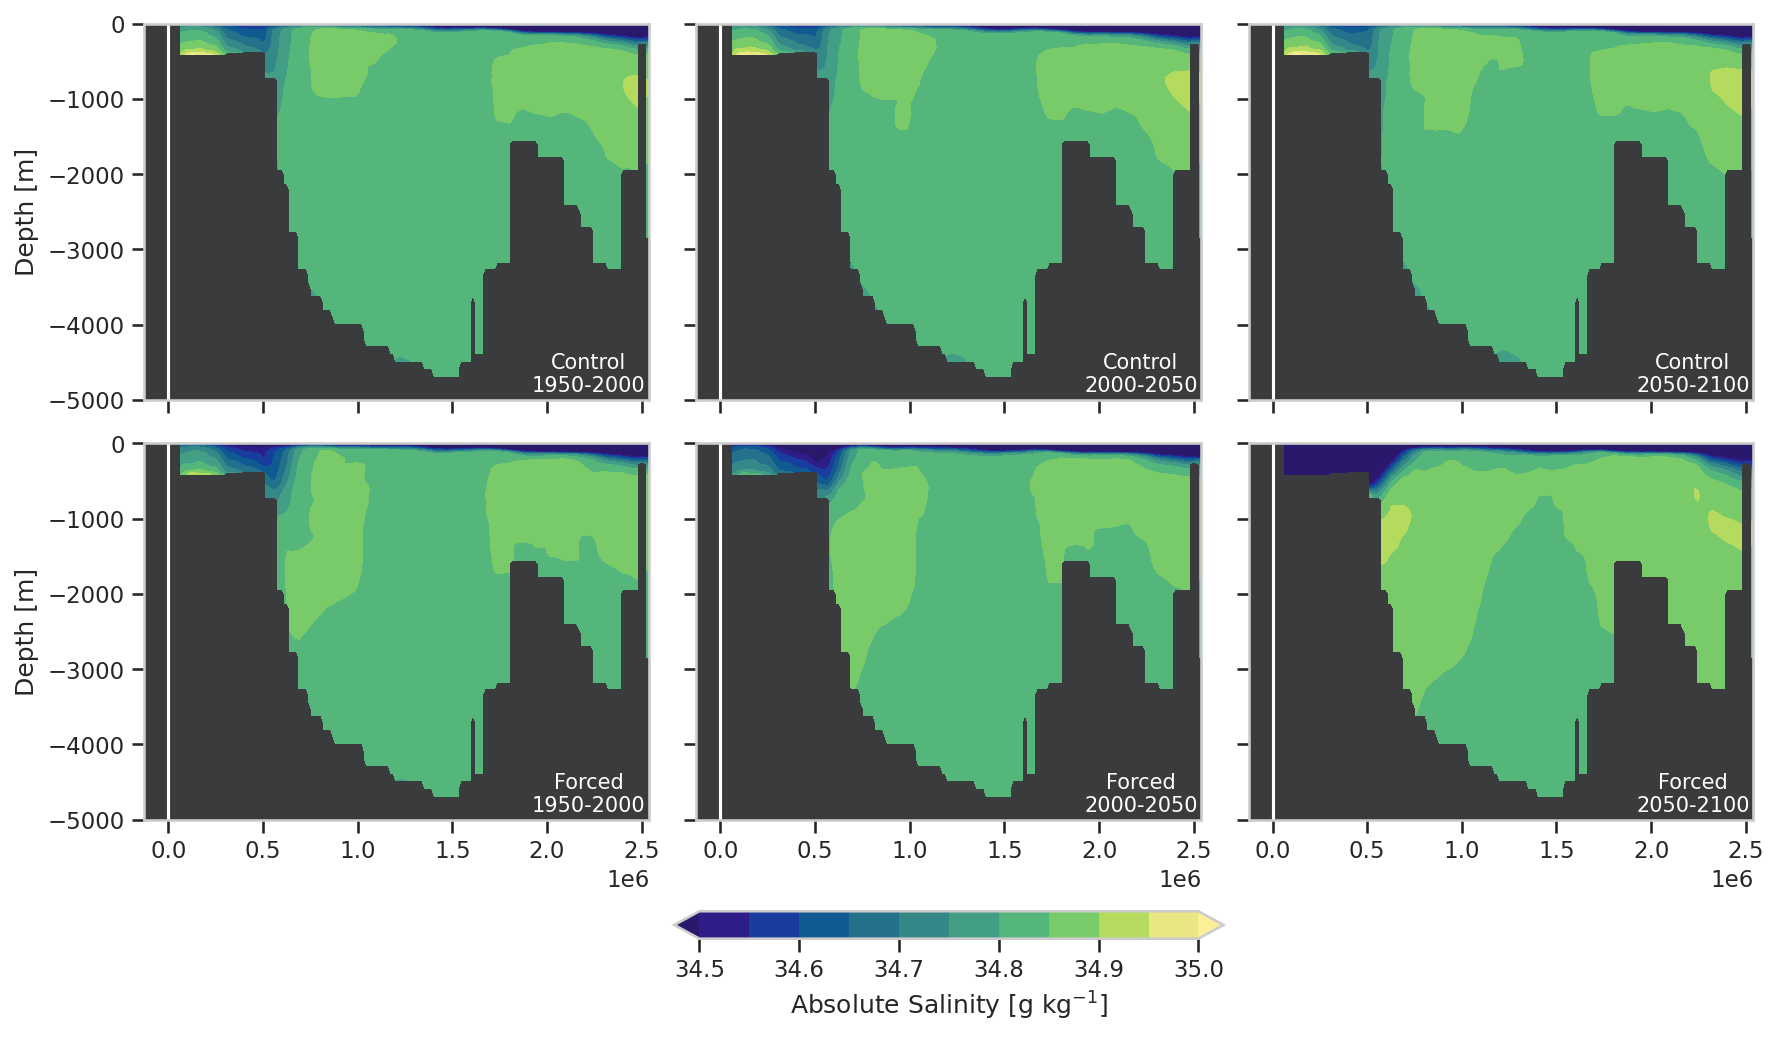

In [14]:
time_slices = [("1950", "2000"), ("2000", "2050"),  ("2050", "2100")]
expts = ["control", "forced"]
variable = "sa"; variable_name = "Absolute Salinity"; 
vmin = 34.5; vmax = 35; levels = np.arange(vmin, vmax + 1e-14, 0.05)
extend = "both"

fig, axes = plt.subplots(2, 3, figsize = (12, 7), sharey = True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):

        cb = plot_zonal_average_period(ds_zonal_avg, variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-5000, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

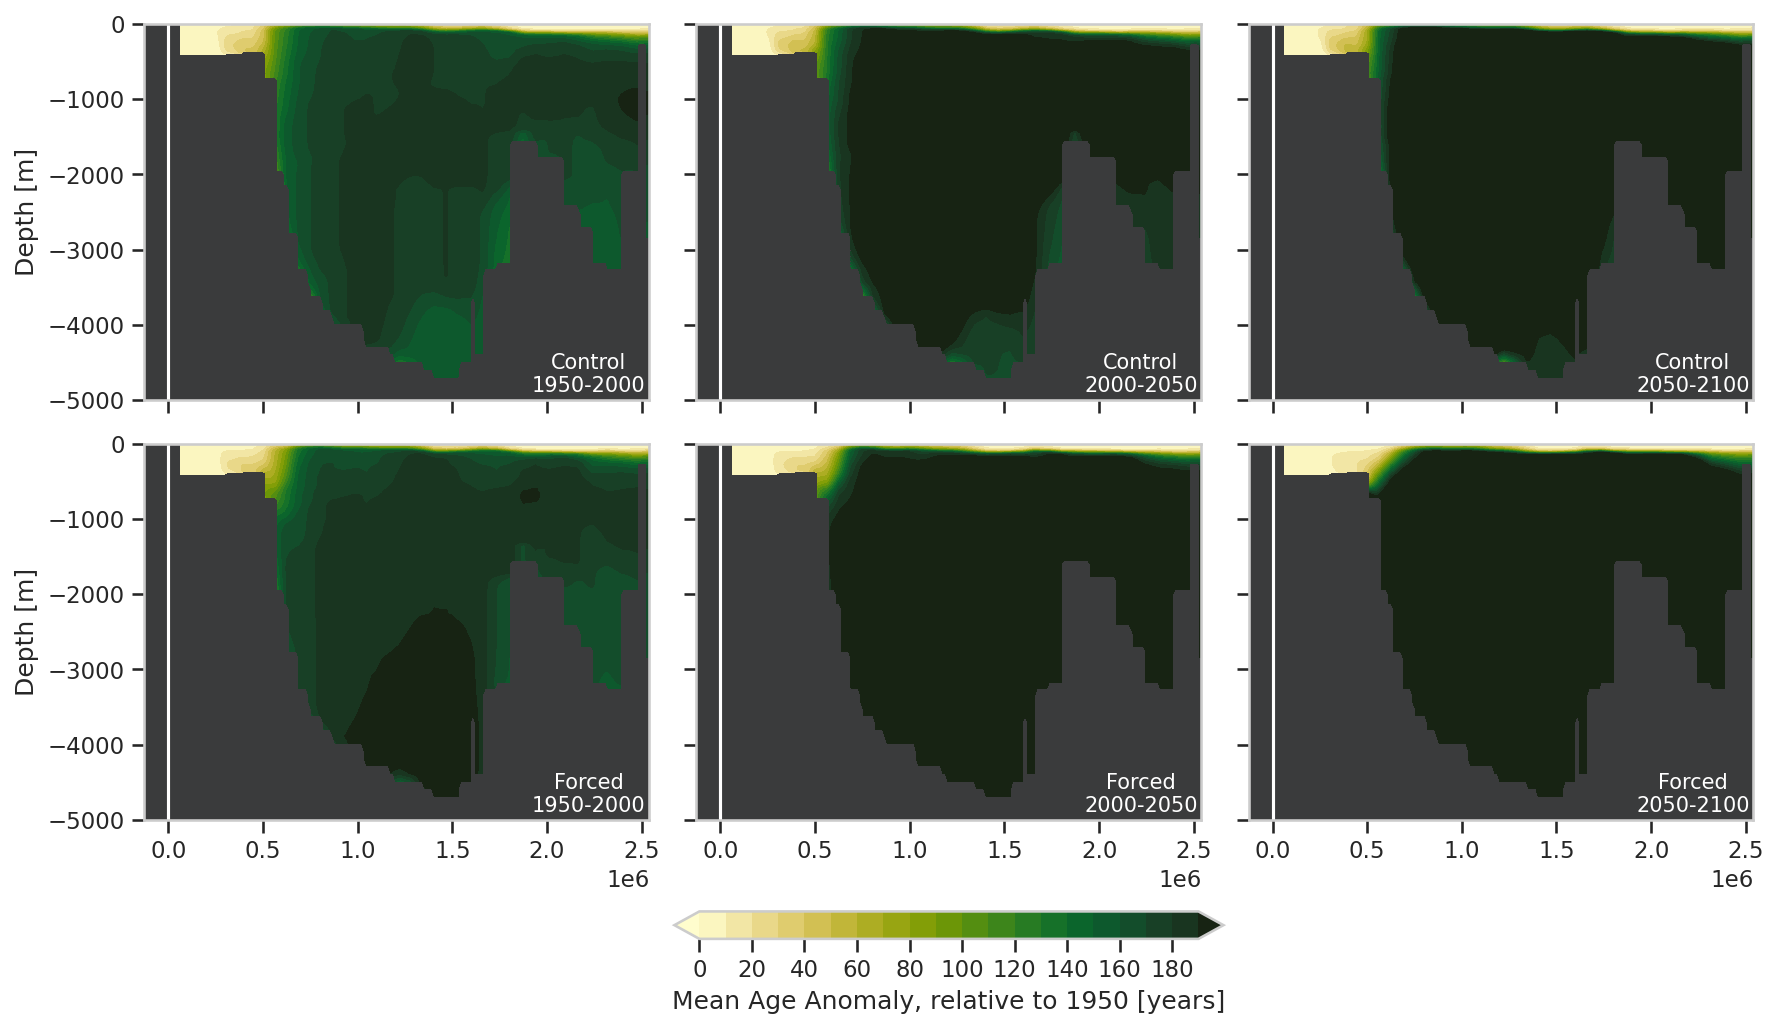

In [15]:
time_slices = [("1950", "2000"), ("2000", "2050"),  ("2050", "2100")]
expts = ["control", "forced"]
variable = "agessc"; variable_name = "Mean Age Anomaly, relative to 1950"; 
vmin = 0; vmax = 200;levels = np.arange(vmin, vmax + 1e-14, 10)
extend = "both"

fig, axes = plt.subplots(2, 3, figsize = (12, 7), sharey = True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):
        
        cb = plot_zonal_average_period(ds_zonal_avg, variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-5000, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

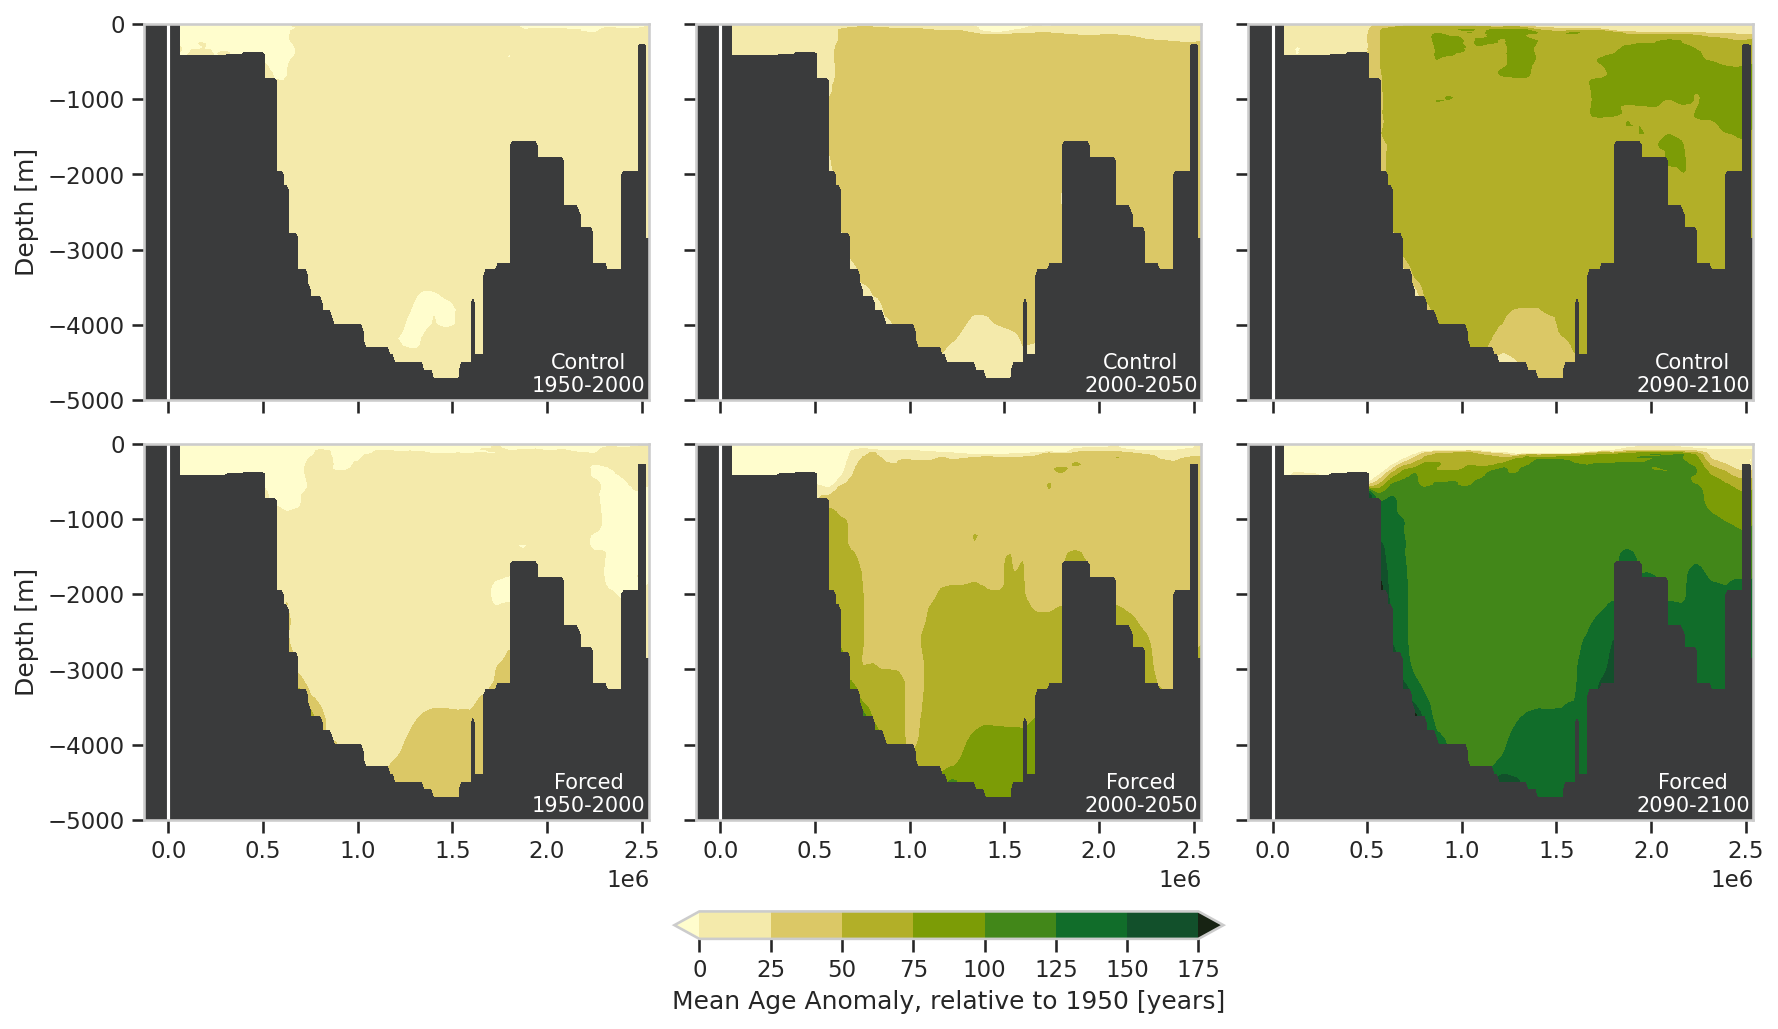

In [19]:
time_slices = [("1950", "2000"), ("2000", "2050"),  ("2090", "2100")]
expts = ["control", "forced"]
variable = "agessc"; variable_name = "Mean Age Anomaly, relative to 1950"; 
vmin = 0; vmax = 200;levels = np.arange(vmin, vmax + 1e-14, 25)
extend = "both"

fig, axes = plt.subplots(2, 3, figsize = (12, 7), sharey = True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):
        cb = plot_zonal_average_period(ds_zonal_avg - ds_zonal_avg.mean("time").sel(exp = "control"), variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-5000, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

In [17]:
ds_zonal_avg["normalized_age"] = (ds_zonal_avg["agessc"] / 350.)

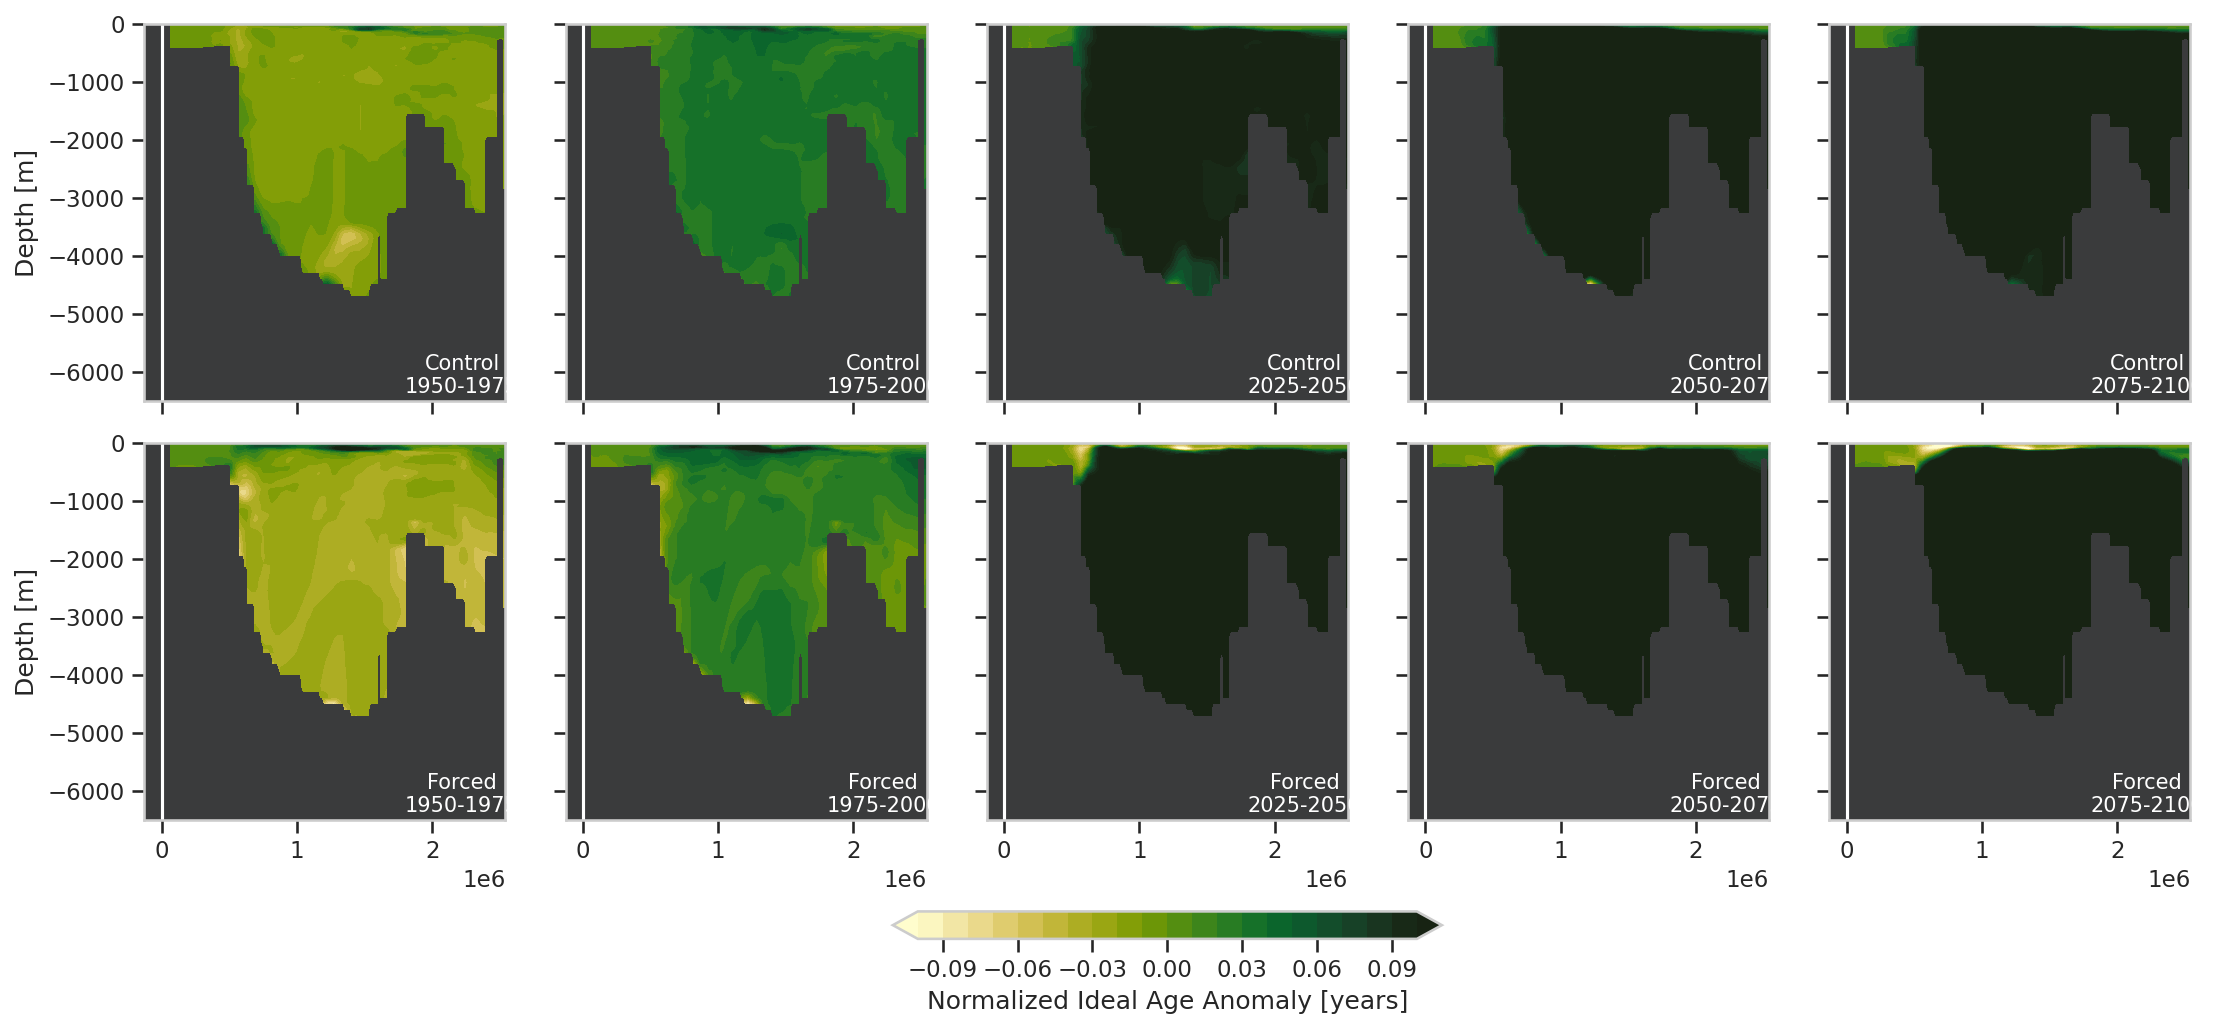

In [27]:
time_slices = [("1950", "1975"), ("1975", "2000"),  ("2025", "2050"), ("2050", "2075"), ("2075", "2100")]
expts = ["control", "forced"]
variable = "normalized_age"; variable_name = "Normalized Ideal Age Anomaly"; 
vmin = -0.1; vmax = 0.1;levels = np.arange(vmin, vmax + 1e-14, 0.01)
extend = "both"

fig, axes = plt.subplots(2, 5, figsize = (15, 7), sharey =True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):
        
        cb = plot_zonal_average_period(ds_zonal_avg - ds_zonal_avg.mean("time"), variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-6500, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

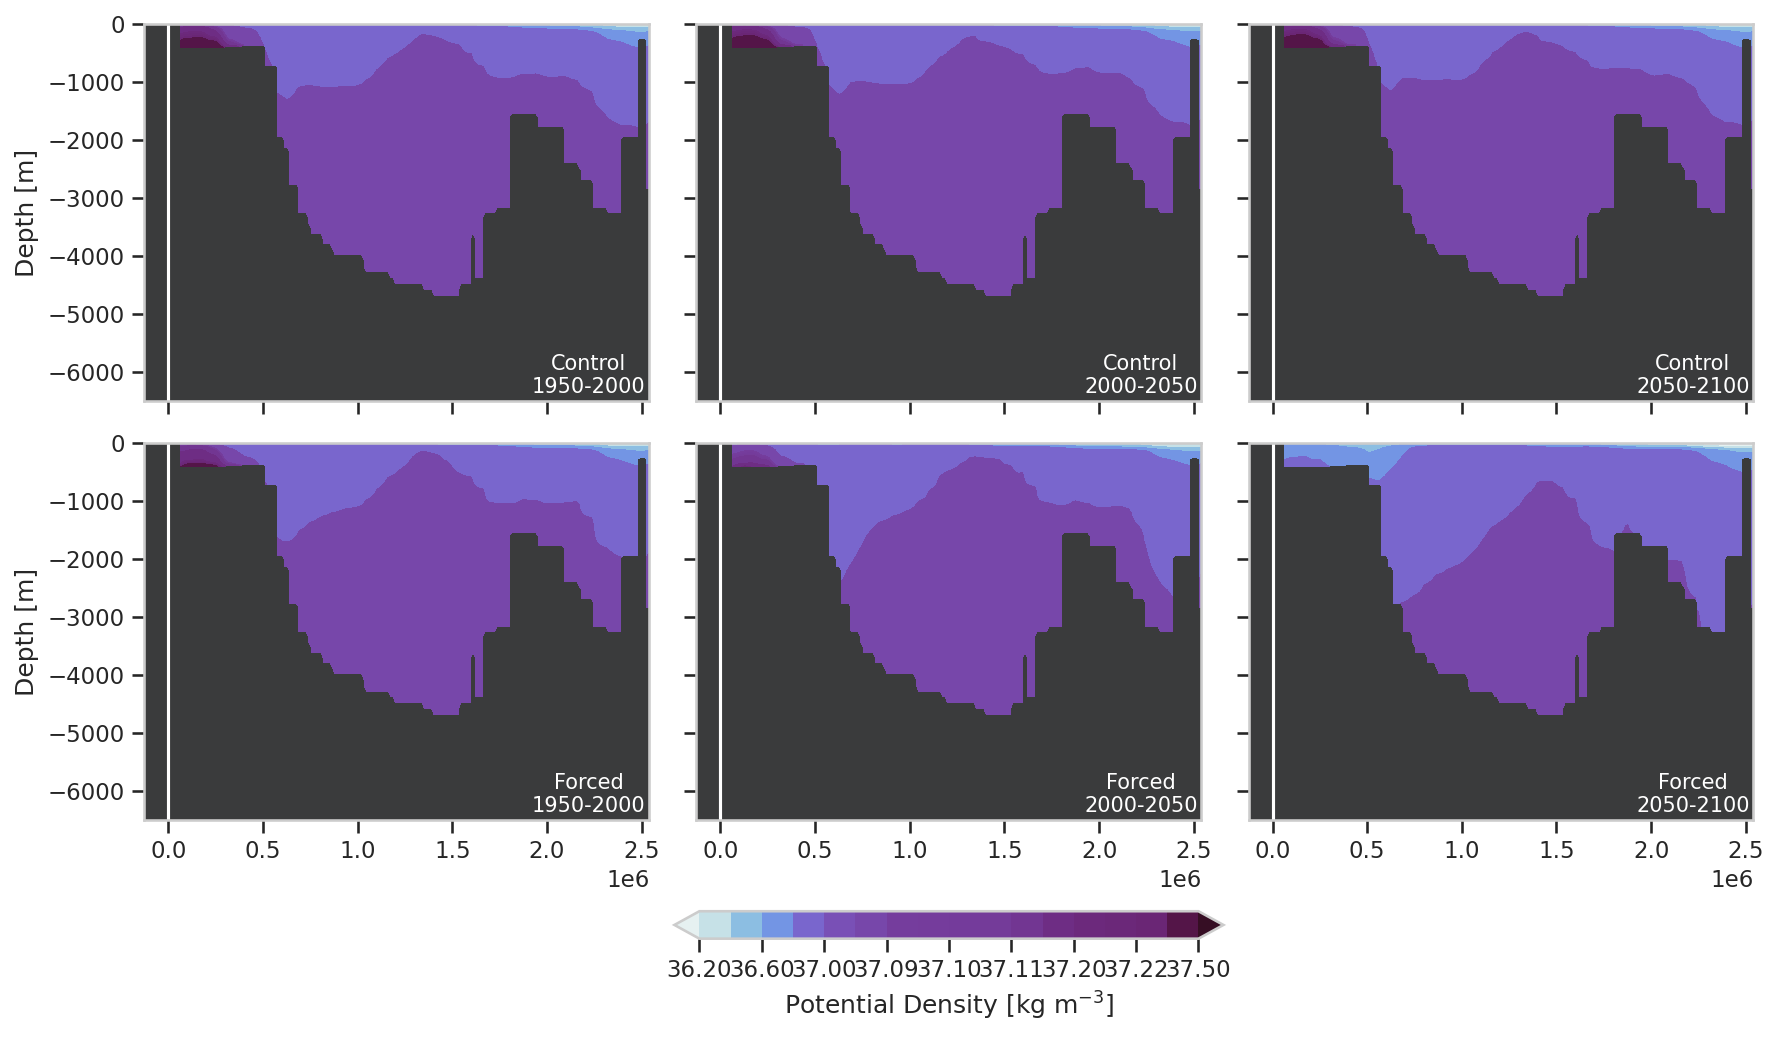

In [26]:
time_slices = [("1950", "2000"), ("2000", "2050"),  ("2050", "2100")]
expts = ["control", "forced"]
variable = "rho2"; variable_name = "Potential Density"; 

levels = np.arange(36.2, 37.4, .2) 
levels = 1.0 * np.sort(np.append(levels, [ 37., 37.09, 37.095, 37.10, 37.105, 37.11, 37.15, 37.21, 37.22, 37.23, 37.5, ]))

vmin = levels.min(); vmax = levels.max();
extend = "both"

fig, axes = plt.subplots(2, 3, figsize = (12, 7), sharey = True, sharex = True)

for (i, expt) in enumerate(expts):
    ax = axes[i]
    for (j, a) in enumerate(ax):

        cb = plot_zonal_average_period(ds_zonal_avg, variable, variable_name, 
                                      time_slices, 
                                      vmin, vmax, levels, extend)
        
    ax[0].set_ylabel("Depth [m]")
    # ax[0].set_xlim(-80, -50)
    ax[0].set_ylim(-6500, 0)

fig.tight_layout()
variable_units = variable_kwargs[variable]["units"]
fig.colorbar(cb, ax = axes, orientation = "horizontal", fraction = 0.03, pad = 0.1, 
            label = variable_name + f" [{variable_units}]")

In [42]:
get_baselines = lambda ds_zonal_avg, var: average_period(ds_zonal_avg[var], slice("1950", "2000"))

ds_zonal_avg["rho2_baseline"] = get_baselines(ds_zonal_avg, "rho2")
ds_zonal_avg["ct_baseline"] = get_baselines(ds_zonal_avg, "ct")
ds_zonal_avg["sa_baseline"] = get_baselines(ds_zonal_avg, "sa")


p_ref = 2000 #2000 dbar reference pressure 

# Calculate thermal expansion coefficient alpha (1/K) at reference pressure
ds_zonal_avg['alpha_baseline'] = xr.apply_ufunc(
    gsw.alpha, ds_zonal_avg["sa_baseline"], ds_zonal_avg["ct_baseline"], p_ref, dask="parallelized"
)

# Calculate the haline contraction coefficient beta (kg/g) at reference pressure
ds_zonal_avg['beta_baseline'] = xr.apply_ufunc(
    gsw.beta, ds_zonal_avg["sa_baseline"], ds_zonal_avg["ct_baseline"], p_ref, dask="parallelized"
)

In [43]:
# Compute the reconstructed anomaly
ds_zonal_avg["rho2_anomaly_reconstructed"] = (
    ds_zonal_avg["rho2_anomaly_ct_contrib"] + ds_zonal_avg["rho2_anomaly_sa_contrib"]
)

fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

# Define variables and titles
variables = [
    ("rho2_anomaly", "Density Anomaly"),
    ("rho2_anomaly_reconstructed", "Reconstructed Density Anomaly"),
    ("rho2_anomaly_ct_contrib", "CT Contribution"),
    ("rho2_anomaly_sa_contrib", "SA Contribution")
]

vmin, vmax = -0.08, 0.08
levels = np.arange(vmin, vmax + 1e-14, 0.01)
# Plot each panel
for ax, (var, title) in zip(axs.flat, variables):
     
    pcm = ds_zonal_avg[var].sel(exp = "forced").plot.contourf(ax = ax, 
                                                     x = "geolat", y = "z_l", 
                                                     vmin=vmin, vmax=vmax, levels = levels,
                                                     add_colorbar = False, 
                                                    cmap = cmo.curl, extend = "both")
    ax.vlines([-50], color  = "white", ymin = ds_zonal_avg.z_l.min(), ymax = ds_zonal_avg.z_l.max())

    ax.set_title(title)
    ax.set_ylabel("")
    ax.set_facecolor("#3A3B3C") 


# ax.set_xlabel("Latitude")

axs[0, 0].set_ylabel("Depth (m)")

fig.colorbar(pcm, ax=axs, label="kg/m³", orientation = "horizontal", fraction = 0.05, pad = 0.2)


KeyError: "No variable named 'rho2_anomaly_ct_contrib'. Variables on the dataset include ['agessc', 'cfc11', 'cfc12', 'sf6', 'rho2', ..., 'rho2_baseline', 'ct_baseline', 'sa_baseline', 'alpha_baseline', 'beta_baseline']"